IMPORT SECTION

In [2]:
import os
from utils.utils import process_data
import tensorflow_datasets as tfds
from tqdm import tqdm
import torch
import matplotlib.pyplot as plt

DOWNLOAD DROID DATA

In [ ]:
 # List of the dataset of OXE to download
dataset_list = ["droid"]
download_dir = f"./data/{dataset_list[0]}" # directory where to download the pytorch tensors needed for offline training
os.makedirs(download_dir, exist_ok=True)

# Load in streaming the dataset
ds = tfds.load(dataset_list[0], data_dir="gs://gresearch/robotics", split="train")

droid_lang_keys = ['language_instruction', 'language_instruction_2', 'language_instruction_3']
num_episodes_to_download = 5
for i, episode in enumerate(tqdm(ds.take(num_episodes_to_download), total=num_episodes_to_download, desc=f"Download {dataset_list[0]} episodes", unit="ep")):
    
    # Per ora metti un limite per testare (es. i primi 50 episodi)
    if i >= num_episodes_to_download: 
        break
    
    print(f"--- Episode {i} received from Cloud")
    video_pt, states_pt, action_pt, language_instructions = process_data(episode=episode, 
                                                                         num_frames=16, 
                                                                         fps=15, 
                                                                         window_second_size=4, 
                                                                         lang_keys=droid_lang_keys)
    if video_pt is not None:
        sample = {
            "video": video_pt,      # [16, 3, 256, 256]
            "states": states_pt,    # [16, 7]
            "actions": action_pt,   # [15, 7]
            "language": language_instructions
        }
        
        file_path = os.path.join(download_dir, f"episode_{i}.pt")
        torch.save(sample, file_path)
        print(f"Saved: {file_path}")
    else:
        tqdm.write(f"Episode {i} passed (less then minimum length)")
        pass



I0000 00:00:1773417907.419305   47304 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773417907.453653   47304 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773417908.270067   47304 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1773417908.374633   47304 google_auth_provider.cc:196] All attempts to get a Google authentication 

--- Episode 0 received from Cloud
Saved: ./data/droid/episode_0.pt
--- Episode 1 received from Cloud
Saved: ./data/droid/episode_1.pt
--- Episode 2 received from Cloud
Saved: ./data/droid/episode_2.pt
--- Episode 3 received from Cloud


Download droid episodes:  80%|████████  | 4/5 [00:40<00:07,  7.69s/ep]

Saved: ./data/droid/episode_3.pt


Download droid episodes: 100%|██████████| 5/5 [01:25<00:00, 18.16s/ep]

--- Episode 4 received from Cloud
Saved: ./data/droid/episode_4.pt


Visualizzando l'episodio con istruzione: Put the black objects into the drawer and close the drawer.


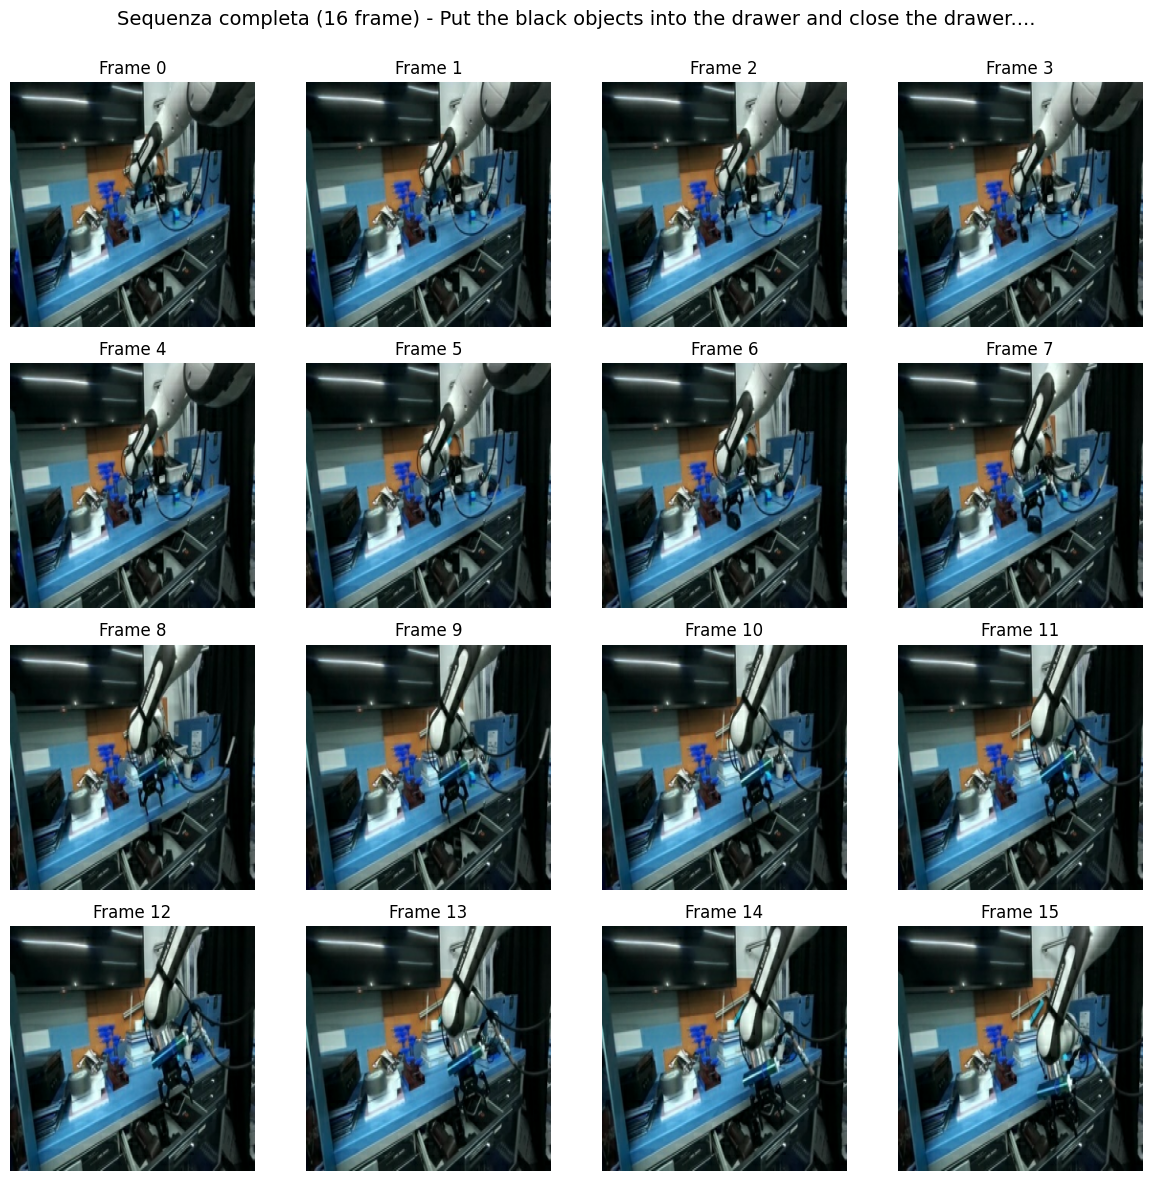


Energia del movimento (norma dell'azione) tra i frame:
[0.06638811 0.05361658 0.05298387 0.0752477  0.09113067 0.11078282
 0.14753282 0.14698519 0.11318822 0.12408529 0.1643594  0.10869722
 0.04927276 0.10385849 0.13924266]


In [5]:
# 1. Carica il file
file_path = "./data/droid/episode_1.pt"
checkpoint = torch.load(file_path)

# 2. Estrazione video e info
video = checkpoint['video']  # [16, 3, 256, 256]
instruction = checkpoint['language'][0]

print(f"Visualizzando l'episodio con istruzione: {instruction}")

# 3. Creazione della griglia 4x4
plt.style.use('default')
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle(f"Sequenza completa (16 frame) - {instruction[:80]}...", fontsize=14)

for i in range(16):
    ax = axes[i // 4, i % 4]
    
    # Prendi il frame i, sposta i canali da [C, H, W] a [H, W, C]
    frame = video[i].permute(1, 2, 0).numpy()
    
    ax.imshow(frame)
    ax.set_title(f"Frame {i}")
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Spazio per il titolo principale
plt.show()

# 4. Verifica dinamica delle azioni
# Calcoliamo la "magnitudo" del movimento per vedere se i frame sono diversi
movement = torch.norm(checkpoint['actions'], dim=1)
print("\nEnergia del movimento (norma dell'azione) tra i frame:")
print(movement.numpy())